# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

## Acknowledgement of Generative AI Use

Generative AI was used as a supplementary aid in translating the original R workflow into Python, troubleshooting code issues, and refining documentation. All final code, analysis, and written explanations were reviewed and validated by me, and I remain fully responsible for the submitted work.


In [1]:
# filter dplyr warning
%load_ext rpy2.ipython
import warnings
warnings.filterwarnings('ignore')

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import statsmodels.formula.api as smf

In [3]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)
raw_data.shape[0]

7214

In [4]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [5]:
df = raw_data[
    [
        "age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
        "priors_count", "days_b_screening_arrest", "decile_score",
        "is_recid", "two_year_recid", "c_jail_in", "c_jail_out"
    ]
].copy()

# Filtering
df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

# Datetime conversion
df["c_jail_in"] = pd.to_datetime(df["c_jail_in"], utc=True)
df["c_jail_out"] = pd.to_datetime(df["c_jail_out"], utc=True)

df.shape[0]

6172

In [6]:
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00


In [7]:
def glimpse(df):
    # Header (match R exactly)
    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]}")

    for col in df.columns:
        dtype = df[col].dtype

        # Match R types
        if "int" in str(dtype):
            dtype_str = "<int>"
        elif "float" in str(dtype):
            dtype_str = "<dbl>"
        elif "datetime" in str(dtype):
            dtype_str = "<dttm>"
        else:
            dtype_str = "<fct>"

        # Get first values (like R glimpse)
        values = [str(x) for x in df[col].head(12)]
        values_str = ", ".join(values)

        # Truncate with ellipsis (exact style)
        if len(df[col]) > 12:
            values_str += "…"

        # Align spacing to match R
        print(f"$ {col:<23} {dtype_str:<6} {values_str}")

glimpse(df)

Rows: 6,172
Columns: 13
$ age                     <int>  69, 34, 24, 44, 41, 43, 39, 27, 23, 37, 41, 47…
$ c_charge_degree         <fct>  F, F, F, M, F, F, M, F, M, M, F, F…
$ race                    <fct>  Other, African-American, African-American, Other, Caucasian, Other, Caucasian, Caucasian, African-American, Caucasian, African-American, Caucasian…
$ age_cat                 <fct>  Greater than 45, 25 - 45, Less than 25, 25 - 45, 25 - 45, 25 - 45, 25 - 45, 25 - 45, Less than 25, 25 - 45, 25 - 45, Greater than 45…
$ score_text              <fct>  Low, Low, Low, Low, Medium, Low, Low, Low, Medium, Low, Low, Low…
$ sex                     <fct>  Male, Male, Male, Male, Male, Male, Female, Male, Male, Female, Male, Female…
$ priors_count            <int>  0, 0, 4, 0, 14, 3, 0, 0, 3, 0, 0, 1…
$ days_b_screening_arrest <dbl>  -1.0, -1.0, -1.0, 0.0, -1.0, -1.0, -1.0, -1.0, 0.0, 0.0, -1.0, -20.0…
$ decile_score            <int>  1, 3, 4, 1, 6, 4, 1, 4, 6, 1, 4, 1…
$ is_recid                

In [8]:
def glimpse(df, n=10):
    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]}\n")

    for col in df.columns:
        dtype = df[col].dtype
        values = ", ".join(map(str, df[col].head(n).tolist()))
        print(f"$ {col:<25} <{dtype}> {values}")

glimpse(df)

Rows: 6,172
Columns: 13

$ age                       <int64> 69, 34, 24, 44, 41, 43, 39, 27, 23, 37
$ c_charge_degree           <object> F, F, F, M, F, F, M, F, M, M
$ race                      <object> Other, African-American, African-American, Other, Caucasian, Other, Caucasian, Caucasian, African-American, Caucasian
$ age_cat                   <object> Greater than 45, 25 - 45, Less than 25, 25 - 45, 25 - 45, 25 - 45, 25 - 45, 25 - 45, Less than 25, 25 - 45
$ score_text                <object> Low, Low, Low, Low, Medium, Low, Low, Low, Medium, Low
$ sex                       <object> Male, Male, Male, Male, Male, Male, Female, Male, Male, Female
$ priors_count              <int64> 0, 0, 4, 0, 14, 3, 0, 0, 3, 0
$ days_b_screening_arrest   <float64> -1.0, -1.0, -1.0, 0.0, -1.0, -1.0, -1.0, -1.0, 0.0, 0.0
$ decile_score              <int64> 1, 3, 4, 1, 6, 4, 1, 4, 6, 1
$ is_recid                  <int64> 0, 1, 1, 0, 1, 0, 0, 0, 1, 0
$ two_year_recid            <int64> 0, 1, 1, 0, 1, 0,

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [9]:
df["length_of_stay"] = (
    pd.to_datetime(df["c_jail_out"].astype(str).str[:10]) -
    pd.to_datetime(df["c_jail_in"].astype(str).str[:10])
).dt.days

df[["length_of_stay", "decile_score"]].corr().iloc[0, 1]

np.float64(0.20732969161470416)

After filtering we have the following demographic breakdown:

In [10]:
df["age_cat"].value_counts(dropna=False)

,count
age_cat,
25 - 45,3532
Less than 25,1347
Greater than 45,1293


In [11]:
df["race"].value_counts(dropna=False)

,count
race,
African-American,3175
Caucasian,2103
Hispanic,509
Other,343
Asian,31
Native American,11


In [12]:
print("Black defendants: %.2f%%" %            (3175 / 6172 * 100))
print("White defendants: %.2f%%" %            (2103 / 6172 * 100))
print("Hispanic defendants: %.2f%%" %         (509  / 6172 * 100))
print("Asian defendants: %.2f%%" %            (31   / 6172 * 100))
print("Native American defendants: %.2f%%" %  (11   / 6172 * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [13]:
df["score_text"].value_counts(dropna=False)

,count
score_text,
Low,3421
Medium,1607
High,1144


In [14]:
pd.crosstab(df["sex"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [15]:
df["sex"].value_counts(dropna=False)

,count
sex,
Male,4997
Female,1175


In [16]:
print("Men: %.2f%%" %   (4997 / 6172 * 100))
print("Women: %.2f%%" % (1175 / 6172 * 100))

Men: 80.96%
Women: 19.04%


In [17]:
(df["two_year_recid"] == 1).sum()

np.int64(2809)

In [18]:
print(f'{(df[df["two_year_recid"] == 1].shape[0] / df.shape[0] * 100):.7g}')

45.51199


Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

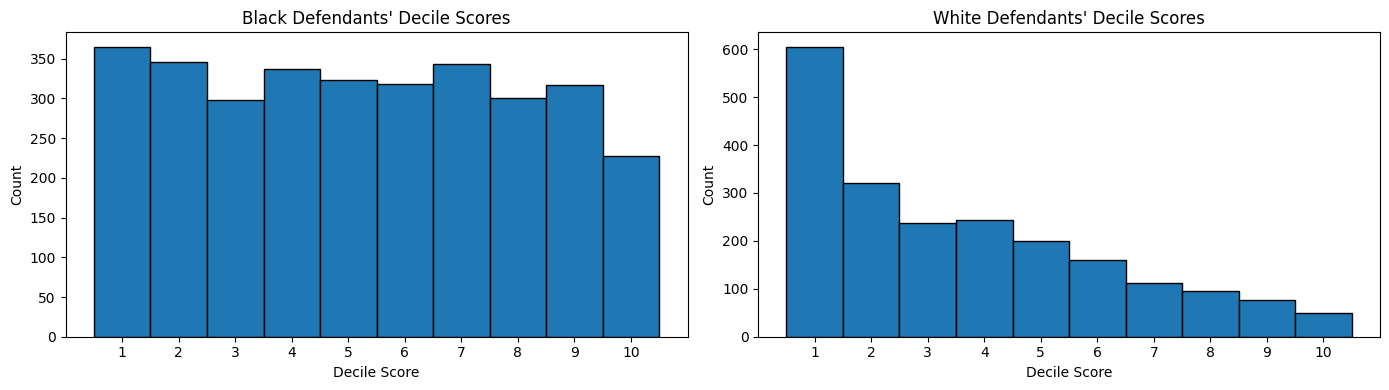

In [19]:
black_scores = df[df["race"] == "African-American"]["decile_score"]
white_scores = df[df["race"] == "Caucasian"]["decile_score"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(black_scores, bins=np.arange(1, 12) - 0.5, edgecolor="black")
axes[0].set_xticks(range(1, 11))
axes[0].set_xlabel("Decile Score")
axes[0].set_ylabel("Count")
axes[0].set_title("Black Defendants' Decile Scores")

axes[1].hist(white_scores, bins=np.arange(1, 12) - 0.5, edgecolor="black")
axes[1].set_xticks(range(1, 11))
axes[1].set_xlabel("Decile Score")
axes[1].set_ylabel("Count")
axes[1].set_title("White Defendants' Decile Scores")

plt.tight_layout()
plt.show()

In [20]:
pd.crosstab(df["decile_score"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [21]:
df["score_factor"] = df["score_text"].apply(lambda x: "HighScore" if x in ["Medium", "High"] else "LowScore")
df["gender_factor"] = df["sex"]
df["age_factor"] = df["age_cat"]
df["race_factor"] = df["race"]
df["crime_factor"] = df["c_charge_degree"]

df["score_binary"] = np.where(df["score_factor"] == "HighScore", 1, 0)

model_glm = smf.logit(
    "score_binary ~ C(gender_factor, Treatment(reference='Male')) + \
     C(age_factor, Treatment(reference='25 - 45')) + \
     C(race_factor, Treatment(reference='Caucasian')) + \
     priors_count + \
     C(crime_factor) + \
     two_year_recid",
    data=df
).fit()

print(model_glm.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Mon, 30 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        13:34:59   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [22]:
import numpy as np

control = np.exp(-1.52554) / (1 + np.exp(-1.52554))
result = np.exp(0.47721) / (1 - control + (control * np.exp(0.47721)))
print(f"{result:.7g}")

1.452841


Women are 19.4% more likely than men to get a higher score.

In [23]:
import numpy as np

control = np.exp(-1.52554) / (1 + np.exp(-1.52554))
result = np.exp(0.22127) / (1 - control + (control * np.exp(0.22127)))
print(f"{result:.7g}")

1.194798


Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [24]:
import numpy as np

control = np.exp(-1.52554) / (1 + np.exp(-1.52554))
result = np.exp(1.30839) / (1 - control + (control * np.exp(1.30839)))
print(f"{result:.7g}")

2.49612


In [25]:
df["pred_prob"] = model_glm.predict(df)
df["pred_class"] = np.where(df["pred_prob"] >= 0.5, "Recid", "No Recid")

In [26]:
TP = ((df["pred_class"] == "Recid") & (df["two_year_recid"] == 1)).sum()
TN = ((df["pred_class"] == "No Recid") & (df["two_year_recid"] == 0)).sum()
FP = ((df["pred_class"] == "Recid") & (df["two_year_recid"] == 0)).sum()
FN = ((df["pred_class"] == "No Recid") & (df["two_year_recid"] == 1)).sum()
n = len(df)

accuracy = (TP + TN) / n
precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan
fpr = FP / (FP + TN) if (FP + TN) > 0 else np.nan
fnr = FN / (FN + TP) if (FN + TP) > 0 else np.nan

# Create a confusion matrix DataFrame for printing
cm_data = {'0': [TN, FP], '1': [FN, TP]}
cm_df = pd.DataFrame(cm_data, index=['No Recid', 'Recid'])
cm_df.columns.name = 'Actual'
cm_df.index.name = 'Predicted'

print("Overall Confusion Matrix")
print(cm_df)
print(f"\nAccuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"FPR       : {fpr:.3f}")
print(f"FNR       : {fnr:.3f}")

Overall Confusion Matrix
Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [27]:
df["actual"] = df["two_year_recid"].astype(int)
df["pred"] = np.where(df["pred_class"] == "Recid", 1, 0)

race_metrics = (
    df.groupby("race")
      .apply(lambda g: pd.Series({
          "n": len(g),
          "TP": ((g["pred"] == 1) & (g["actual"] == 1)).sum(),
          "TN": ((g["pred"] == 0) & (g["actual"] == 0)).sum(),
          "FP": ((g["pred"] == 1) & (g["actual"] == 0)).sum(),
          "FN": ((g["pred"] == 0) & (g["actual"] == 1)).sum()
      }))
      .reset_index()
)

race_metrics["Accuracy"] = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"] = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"] = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)

race_metrics = race_metrics.sort_values("n", ascending=False)
race_metrics

,race,n,TP,TN,FP,FN,Accuracy,Precision,Recall,FPR,FNR
0,African-American,3175,1373,959,555,288,0.734,0.712,0.827,0.367,0.173
2,Caucasian,2103,381,1148,133,441,0.727,0.741,0.464,0.104,0.536
3,Hispanic,509,81,306,14,108,0.760,0.853,0.429,0.044,0.571
5,Other,343,22,216,3,102,0.694,0.880,0.177,0.014,0.823
1,Asian,31,2,22,1,6,0.774,0.667,0.250,0.043,0.750
4,Native American,11,5,2,4,0,0.636,0.556,1.000,0.667,0.000


In [28]:
caucasian_fpr = race_metrics.loc[race_metrics["race"] == "Caucasian", "FPR"].values[0]
caucasian_fnr = race_metrics.loc[race_metrics["race"] == "Caucasian", "FNR"].values[0]

disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()
disparity["delta_FPR"] = (disparity["FPR"] - caucasian_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - caucasian_fnr).round(3)

disparity

,race,n,FPR,FNR,delta_FPR,delta_FNR
0,African-American,3175,0.367,0.173,0.263,-0.363
2,Caucasian,2103,0.104,0.536,0.000,0.000
3,Hispanic,509,0.044,0.571,-0.060,0.035
5,Other,343,0.014,0.823,-0.090,0.287
1,Asian,31,0.043,0.750,-0.061,0.214
4,Native American,11,0.667,0.000,0.563,-0.536


Homework 2

Step 0 — Train / test split

In [29]:
from sklearn.model_selection import train_test_split

# Define features and target based on the logistic regression model
features = [
    "gender_factor", "age_factor", "race_factor",
    "priors_count", "crime_factor", "two_year_recid"
]
target = "score_binary"

# X and y from the cleaned COMPAS cohort (Lecture 01)
X = df[features]
y = df[target].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 6), Test: (1235, 6)


Step 1 — Fit logistic regression and gradient-boosted tree

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define numeric and categorical features based on the `features` list and their types
numeric_features = ['priors_count', 'two_year_recid']
category_features = ['gender_factor', 'age_factor', 'race_factor', 'crime_factor']

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), category_features),
])

# Logistic regression (GLM-- interpretable by design)
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipeline.fit(X_train, y_train)

# Gradient-boosted tree (black-box)
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42))
])
gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['priors_count',
                                                   'two_year_recid']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender_factor',
                                                   'age_factor', 'race_factor',
                                                   'crime_factor'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

Step 2 — Compare model performance by race

In [31]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)

def group_metrics(pipeline, X, y, group_col="race_factor"):
    results = []
    X_ = X.copy()
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]
    for group, gdf in X_.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(
            gdf["actual"], gdf["pred"]
        ).ravel()
        results.append({
            "race" : group,
            "n" : len(gdf),
            "accuracy" : round(accuracy_score(
                gdf["actual"], gdf["pred"]), 3),
            "FPR" : round(fp / (fp + tn), 3),
            "FNR" : round(fn / (fn + tp), 3),
            "AUC" : round(roc_auc_score(
                gdf["actual"],
                gdf["pred_prob"]), 3),
        })
    return pd.DataFrame(results).sort_values("n", ascending=False)

print(" Logistic Regression ")
print(group_metrics(lr_pipeline, X_test, y_test))
print("\n Gradient-Boosted Tree ")
print(group_metrics(gbt_pipeline, X_test, y_test))

 Logistic Regression 
               race    n  accuracy    FPR    FNR    AUC
0  African-American  634     0.737  0.387  0.177  0.820
2         Caucasian  412     0.750  0.109  0.562  0.794
3          Hispanic  108     0.824  0.063  0.483  0.831
5             Other   71     0.803  0.019  0.765  0.852
1             Asian    8     0.750  0.000  1.000  0.667
4   Native American    2     0.500  1.000  0.000  1.000

 Gradient-Boosted Tree 
               race    n  accuracy    FPR    FNR    AUC
0  African-American  634     0.708  0.360  0.244  0.808
2         Caucasian  412     0.784  0.099  0.477  0.791
3          Hispanic  108     0.815  0.089  0.448  0.833
5             Other   71     0.845  0.019  0.588  0.846
1             Asian    8     0.625  0.167  1.000  0.667
4   Native American    2     0.500  1.000  0.000  1.000


Step 3 — LIME explanations: Black vs White defendant

In [32]:
!pip install lime
from lime.lime_tabular import LimeTabularExplainer
import numpy as np
X_train_enc = preprocessor.fit_transform(X_train)
explainer = LimeTabularExplainer(
    training_data = X_train_enc,
    feature_names = (numeric_features +
        list(preprocessor
             .named_transformers_["cat"]
             .get_feature_names_out(
                category_features))),
    class_names = ["No Recid", "Recid"],
    mode = "classification",
    discretize_continuous= True,
    random_state = 42
)
# Select a Black and White defendant with similar predicted risk
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

black_df = X_test_copy[X_test_copy["race_factor"] == "African-American"].sort_values("pred_prob")
black_idx = black_df.index[len(black_df) // 2]

white_df = X_test_copy[X_test_copy["race_factor"] == "Caucasian"].sort_values("pred_prob")
white_idx = white_df.index[len(white_df) // 2]

# Generate and display LIME explanations
for label, idx in [("Black defendant", black_idx),
                   ("White defendant", white_idx)]:
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    exp = explainer.explain_instance(
        data_row = row_enc[0],
        predict_fn= gbt_pipeline["classifier"].predict_proba,
        num_features=6
    )
    print(f"\n LIME: {label} ")
    print(f"Predicted probability: "
          f"{X_test_prob[X_test.index.get_loc(idx)]:.3f}")
    for feat, weight in exp.as_list():
        print(f" {feat:<40} {weight:+.4f}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=a259a87205086d3181e1c3d5b0c7ce240c754e5b3fa06431f828e7e9e842fad9
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime

 LIME: Black defendant 
Predicted probability: 0.594
 age_factor_Less than 25 <= 0.00          -0.3523
 age_factor_Greater than 45 <= 0.00       +0.2269
 0.00 < race_factor_African-American <= 1.00 +0.0941
 -0.92 < two_year_recid <= 1.09           +0.0936
 race_factor_Hispanic <= 0.00             +0.0928
 -0.47 < priors_count <= 0.17             -0.0901

 LIME: White defendant 
Predicted probability: 0.241
 race_factor_Native American <= 0.00      -0.4254
 age_factor_Less than 25 <= 0.00          -0.3536
 -0.68 < priors_count <= -0.47            -0.2688
 age_factor_Greater than 45 <= 0.00  

Step 4 — SHAP beeswarm and waterfall: Black vs White

 93%|=================== | 1151/1235 [00:14<00:01]       

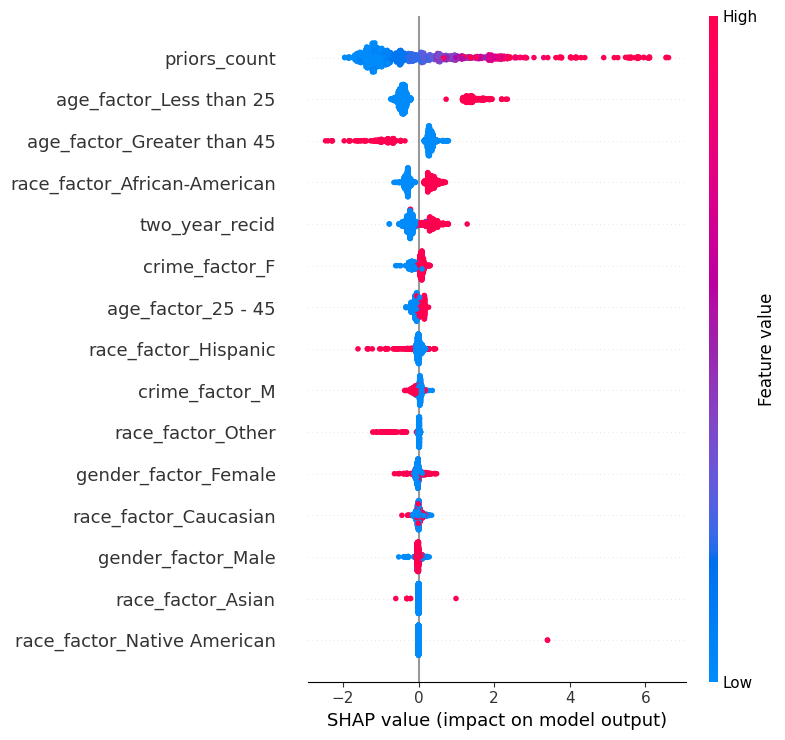

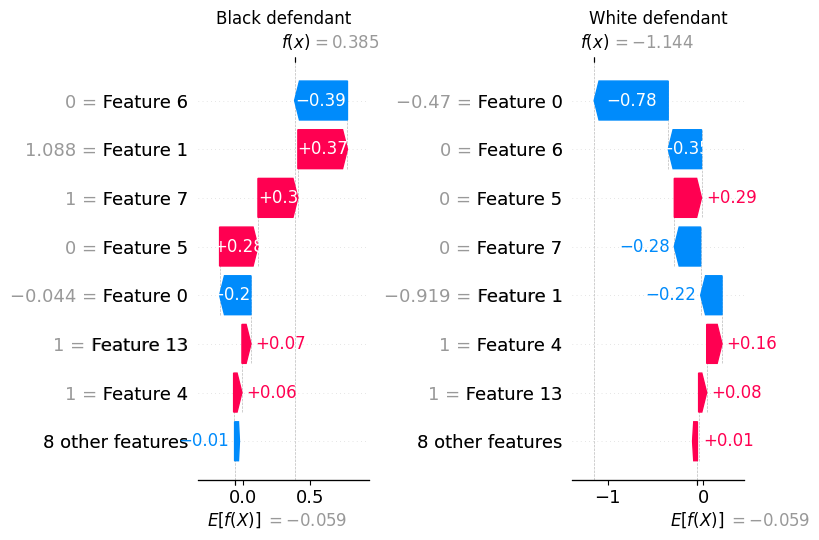

In [33]:
import shap
import matplotlib.pyplot as plt
X_test_enc = preprocessor.transform(X_test)
feat_names = (
    numeric_features +
    list(preprocessor
    .named_transformers_["cat"]
    .get_feature_names_out(category_features)))
explainer_shap = shap.Explainer(
    gbt_pipeline["classifier"],
    shap.maskers.Independent(X_test_enc, max_samples=100)
)
shap_values = explainer_shap(X_test_enc, check_additivity=False)
# Global beeswarm
shap.summary_plot(shap_values, X_test_enc,
feature_names=feat_names)
# Waterfall: Black defendant
black_loc = X_test.index.get_loc(black_idx)
white_loc = X_test.index.get_loc(white_idx)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, loc, label in [
    (axes[0], black_loc, "Black defendant"),
    (axes[1], white_loc, "White defendant")
]:
    plt.sca(ax)
    shap.waterfall_plot(shap_values[loc],
        max_display=8,
        show=False)
    ax.set_title(label)
plt.tight_layout()
plt.show()

Step 5 — Counterfactuals with DiCE: Black vs White

In [34]:
!pip install dice-ml
import dice_ml
from dice_ml import Dice
# DiCE requires a pandas DataFrame and a wrapped model
dice_data = dice_ml.Data(
dataframe = pd.concat([X_train, y_train], axis=1),
continuous_features = numeric_features,
outcome_name = target
)
dice_model = dice_ml.Model(
model = gbt_pipeline,
backend = "sklearn",
model_type = "classifier"
)
exp_dice = Dice(dice_data, dice_model, method="random")
for label, idx in [("Black defendant", black_idx),
("White defendant", white_idx)]:
    query = X_test.loc[[idx]]
    cf = exp_dice.generate_counterfactuals(
    query,
    total_CFs = 3,
    desired_class = "opposite",
    # Correcting permitted_range for categorical features and feature names
    permitted_range = {
        "priors_count": [0, 38],
        "age_factor": ['Greater than 45', '25 - 45', 'Less than 25'],
        "crime_factor": ['F', 'M']
    },
    # Correcting features_to_vary to use the names in X_test
    features_to_vary = ["age_factor", "priors_count", "crime_factor"]
    )
    print(f"\n DiCE counterfactuals: {label} ")
    cf.visualize_as_dataframe(show_only_changes=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 30.5 MB/s eta 0:00:00


100%|██████████| 1/1 [00:00<00:00,  1.55it/s]


 DiCE counterfactuals: Black defendant 
Query instance (original outcome : 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,Male,25 - 45,African-American,3,F,1,1



Diverse Counterfactual set (new outcome: 0)


...

100%|██████████| 1/1 [00:00<00:00,  1.54it/s]


 DiCE counterfactuals: White defendant 
Query instance (original outcome : 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,Male,25 - 45,Caucasian,1,F,0,0



Diverse Counterfactual set (new outcome: 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,-,-,-,14,-,-,1
1,-,-,-,26,M,-,1
2,-,-,-,15,-,-,1


In [35]:
# Install shap if needed
!pip install shap -q

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
# Transform test data using the fitted preprocessor
X_test_enc = preprocessor.transform(X_test)
X_train_enc = preprocessor.transform(X_train)

# Convert sparse matrices to dense if needed
if hasattr(X_test_enc, "toarray"):
    X_test_enc = X_test_enc.toarray()

if hasattr(X_train_enc, "toarray"):
    X_train_enc = X_train_enc.toarray()

# Feature names after one-hot encoding
feat_names = (
    numeric_features +
    list(
        preprocessor.named_transformers_["cat"].get_feature_names_out(category_features)
    )
)

X_test_enc_df = pd.DataFrame(X_test_enc, columns=feat_names, index=X_test.index)

In [37]:
clf = gbt_pipeline.named_steps["classifier"]

tree_explainer = shap.TreeExplainer(clf)
shap_matrix = tree_explainer.shap_values(X_test_enc, check_additivity=False)

if isinstance(shap_matrix, list):
    shap_matrix = shap_matrix[1]
    base_value = tree_explainer.expected_value[1]
else:
    base_value = tree_explainer.expected_value

shap_values = shap.Explanation(
    values=shap_matrix,
    base_values=np.repeat(base_value, X_test_enc.shape[0]),
    data=X_test_enc,
    feature_names=feat_names
)

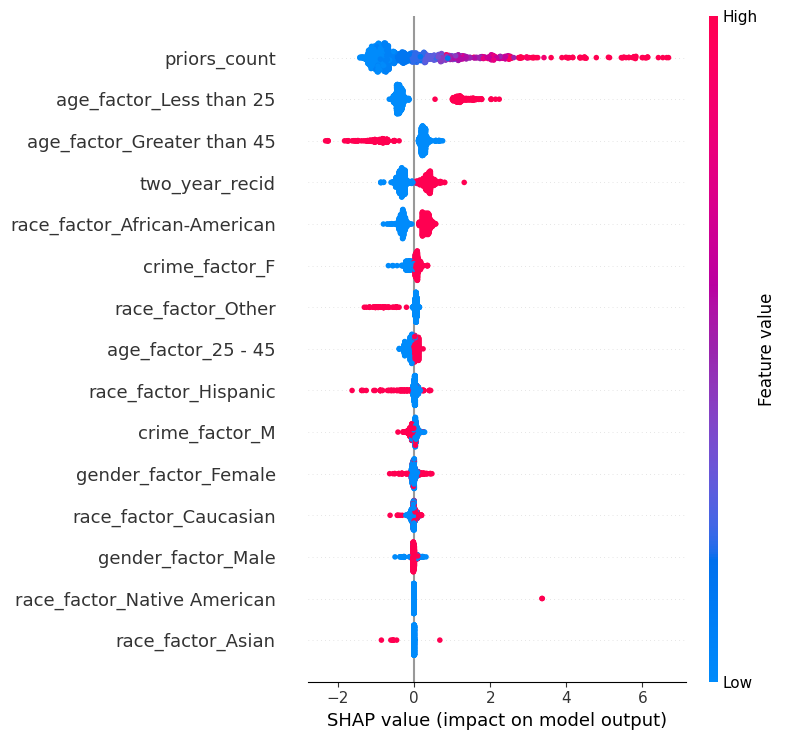

In [38]:
# Beeswarm summary plot
shap.summary_plot(
    shap_values.values,
    X_test_enc_df,
    feature_names=feat_names
)

In [39]:
# Predicted probabilities on test set
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = gbt_pipeline.predict_proba(X_test)[:, 1]

# Restrict to Black and White defendants
black_df = X_test_copy[X_test_copy["race_factor"] == "African-American"].sort_values("pred_prob")
white_df = X_test_copy[X_test_copy["race_factor"] == "Caucasian"].sort_values("pred_prob")

# Highest-risk and lowest-risk in each racial group
selected_cases = [
    ("African-American", "Lowest risk", black_df.index[0]),
    ("African-American", "Highest risk", black_df.index[-1]),
    ("Caucasian", "Lowest risk", white_df.index[0]),
    ("Caucasian", "Highest risk", white_df.index[-1]),
]

selected_cases

[('African-American', 'Lowest risk', np.int64(4008)),
 ('African-American', 'Highest risk', np.int64(5311)),
 ('Caucasian', 'Lowest risk', np.int64(2517)),
 ('Caucasian', 'Highest risk', np.int64(2441))]

1. Select highest-risk and lowest-risk defendant in every racial group

In [40]:
selected_cases = []

for race_group in X_test_copy["race_factor"].dropna().unique():
    group_df = X_test_copy[X_test_copy["race_factor"] == race_group].sort_values("pred_prob")

    if len(group_df) == 0:
        continue

    lowest_idx = group_df.index[0]
    highest_idx = group_df.index[-1]

    selected_cases.append((race_group, "Lowest risk", lowest_idx))
    selected_cases.append((race_group, "Highest risk", highest_idx))

selected_cases

[('African-American', 'Lowest risk', np.int64(4008)),
 ('African-American', 'Highest risk', np.int64(5311)),
 ('Other', 'Lowest risk', np.int64(6887)),
 ('Other', 'Highest risk', np.int64(3309)),
 ('Asian', 'Lowest risk', np.int64(5756)),
 ('Asian', 'Highest risk', np.int64(7123)),
 ('Caucasian', 'Lowest risk', np.int64(2517)),
 ('Caucasian', 'Highest risk', np.int64(2441)),
 ('Hispanic', 'Lowest risk', np.int64(1815)),
 ('Hispanic', 'Highest risk', np.int64(2840)),
 ('Native American', 'Lowest risk', np.int64(1476)),
 ('Native American', 'Highest risk', np.int64(1168))]

2. Generate waterfall plots for all racial groups


African-American - Lowest risk
Predicted probability: 0.021


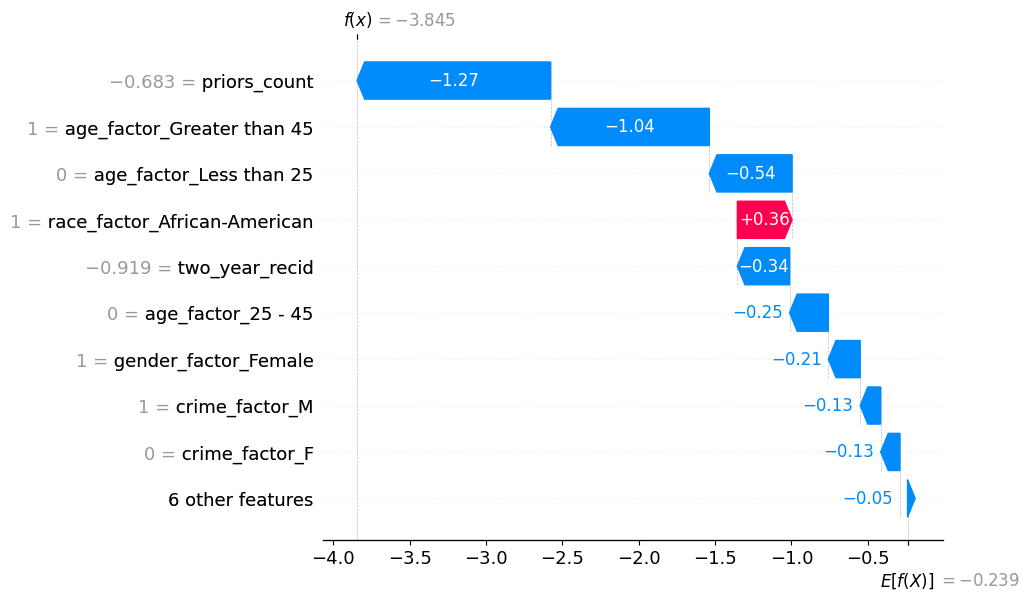


African-American - Highest risk
Predicted probability: 0.999


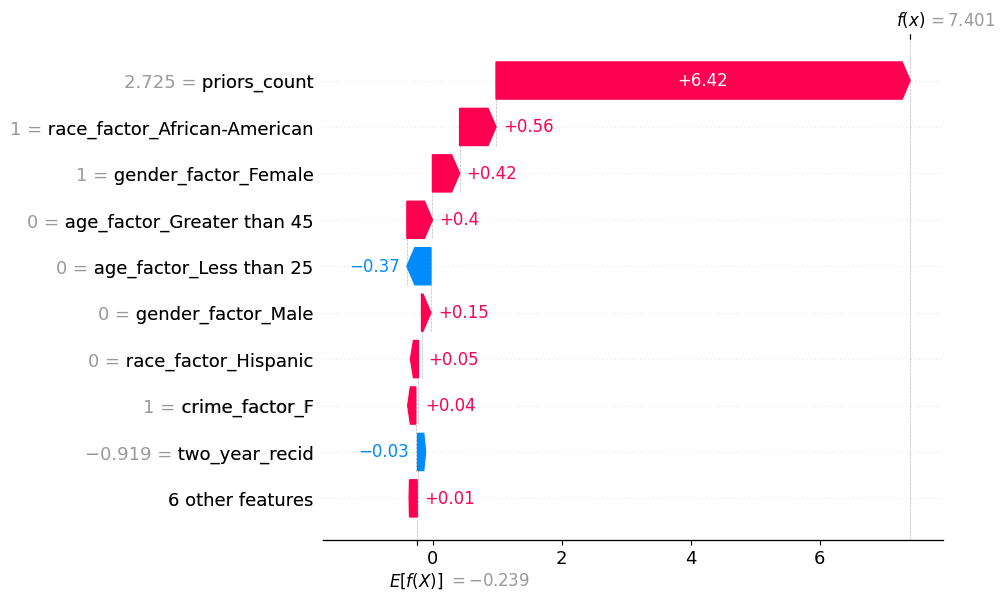


Other - Lowest risk
Predicted probability: 0.013


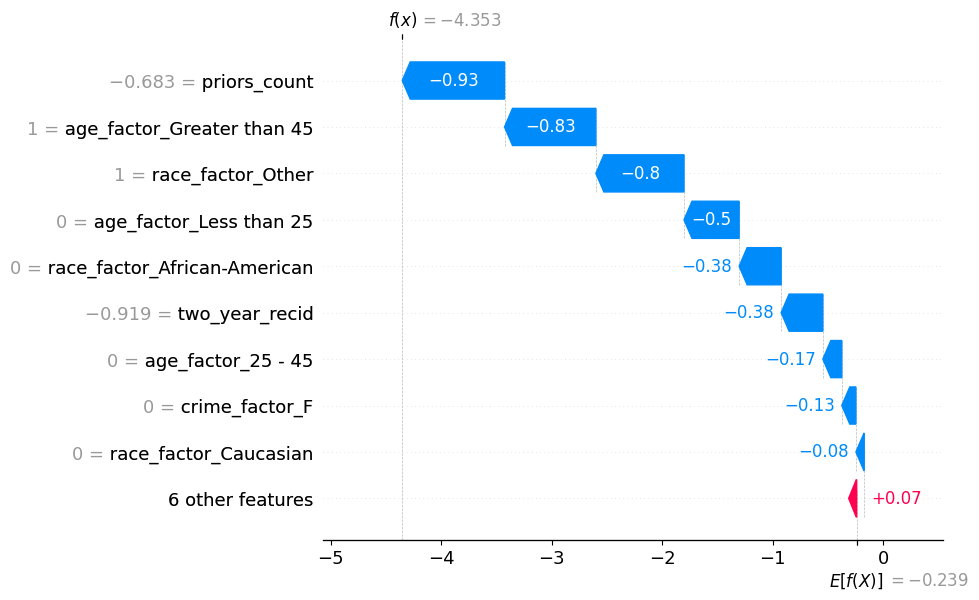


Other - Highest risk
Predicted probability: 0.984


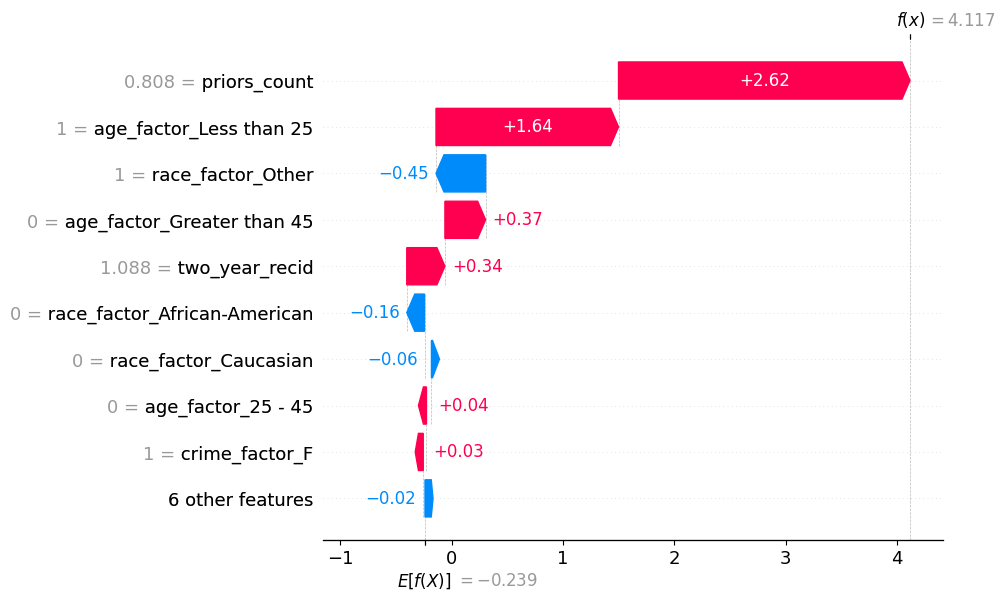


Asian - Lowest risk
Predicted probability: 0.023


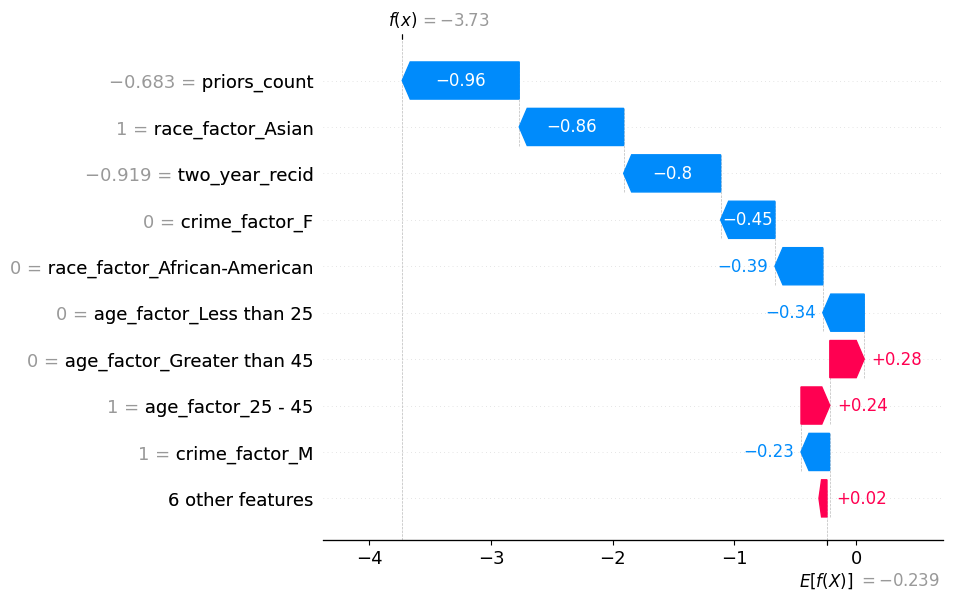


Asian - Highest risk
Predicted probability: 0.865


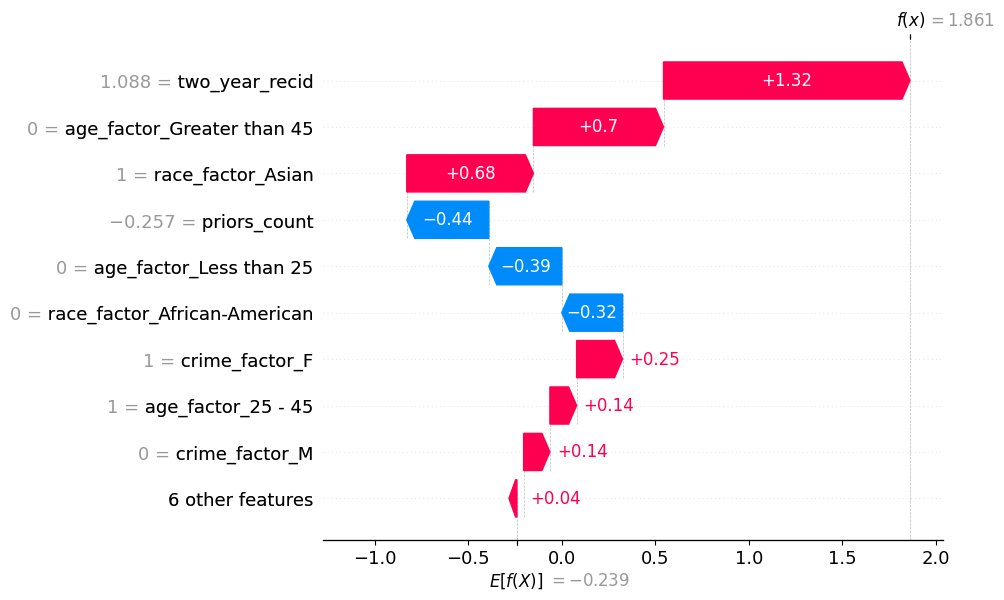


Caucasian - Lowest risk
Predicted probability: 0.017


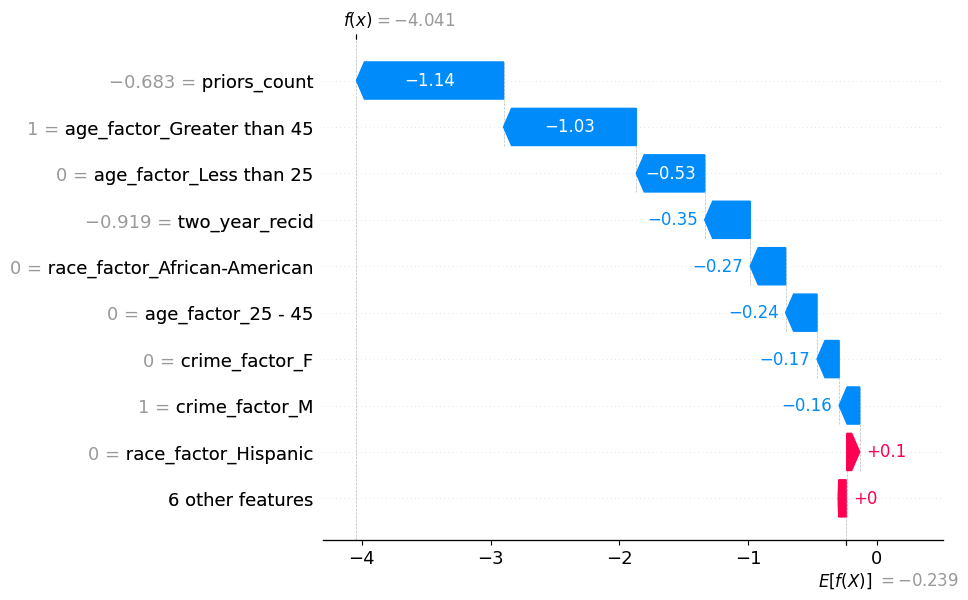


Caucasian - Highest risk
Predicted probability: 0.995


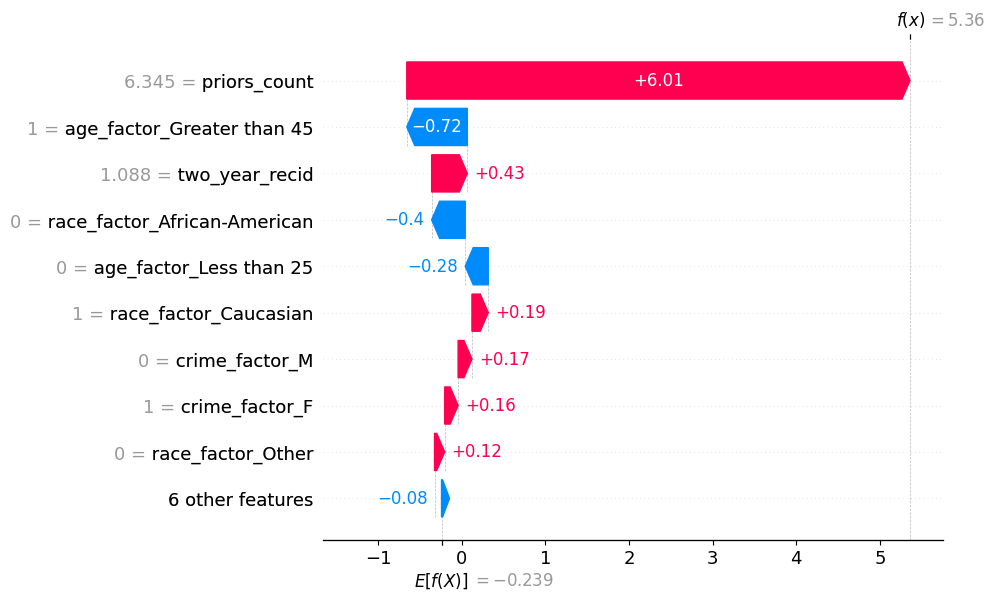


Hispanic - Lowest risk
Predicted probability: 0.002


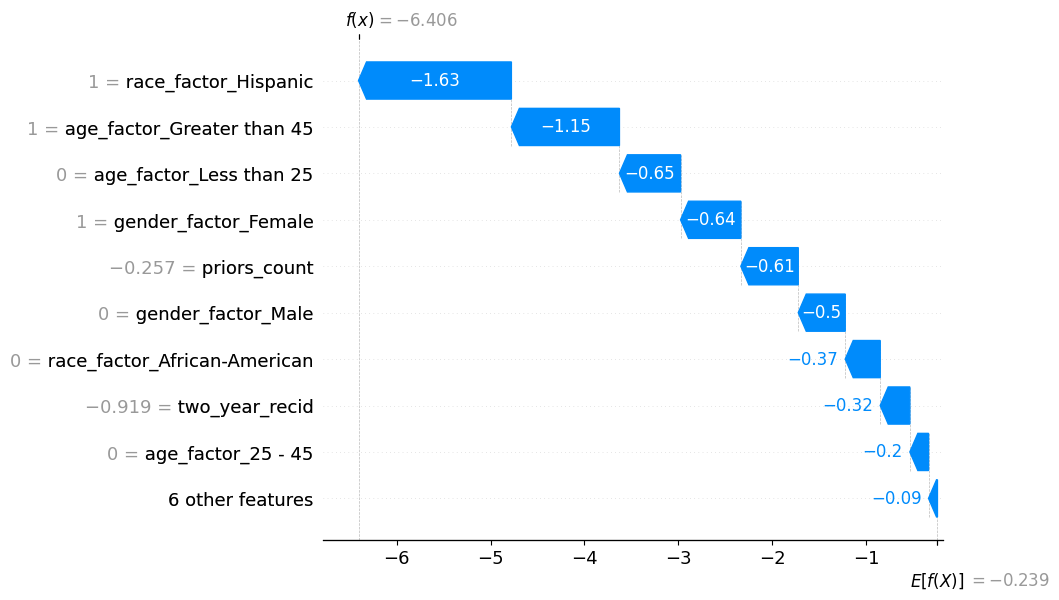


Hispanic - Highest risk
Predicted probability: 0.988


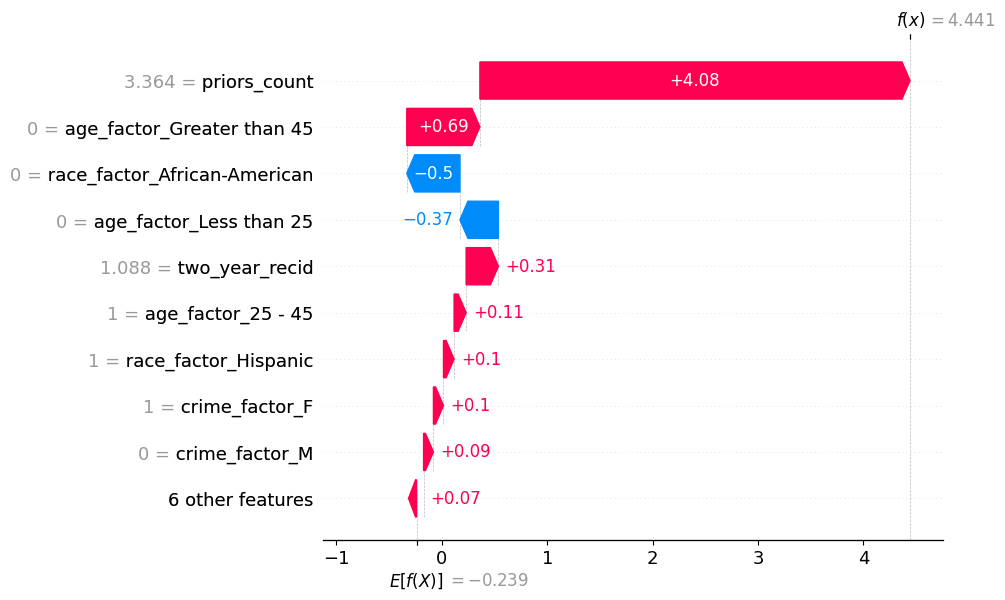


Native American - Lowest risk
Predicted probability: 0.972


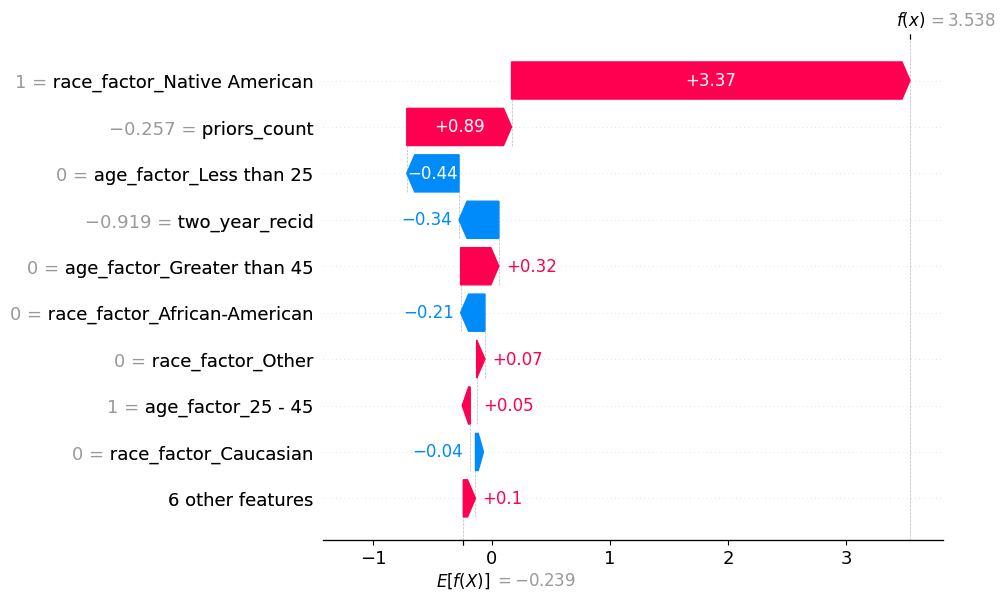


Native American - Highest risk
Predicted probability: 0.989


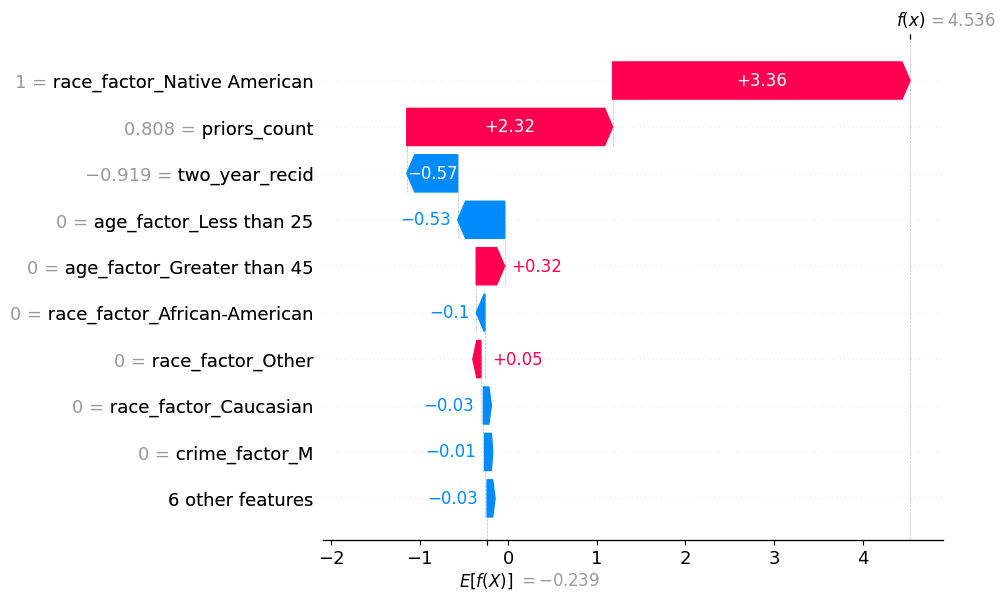

In [41]:
for race_group, risk_label, idx in selected_cases:
    loc = X_test.index.get_loc(idx)

    print(f"\n{race_group} - {risk_label}")
    print(f"Predicted probability: {X_test_copy.loc[idx, 'pred_prob']:.3f}")

    shap.plots.waterfall(shap_values[loc], max_display=10)
    plt.show()

1. Install and import LIME

In [42]:
!pip install lime -q

from lime.lime_tabular import LimeTabularExplainer
import numpy as np

2. Build the LIME explainer

In [43]:
feature_names = (
    numeric_features +
    list(preprocessor.named_transformers_["cat"].get_feature_names_out(category_features))
)

explainer_lime = LimeTabularExplainer(
    training_data=X_train_enc,
    feature_names=feature_names,
    class_names=["No Recid", "Recid"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

3. Run LIME on the same four individuals

In [44]:
for race_group, risk_label, idx in selected_cases:
    loc = X_test.index.get_loc(idx)
    row_enc = X_test_enc[loc]

    exp = explainer_lime.explain_instance(
        data_row=row_enc,
        predict_fn=clf.predict_proba,
        num_features=10
    )

    print("=" * 60)
    print(f"Race group: {race_group}")
    print(f"Case: {risk_label}")
    print(f"Predicted probability: {X_test_copy.loc[idx, 'pred_prob']:.3f}")
    print("=" * 60)

    for feat, weight in exp.as_list():
        print(f"{feat:<45} {weight:+.4f}")

    print("\n")

Race group: African-American
Case: Lowest risk
Predicted probability: 0.021
race_factor_Native American <= 0.00           -0.4353
age_factor_Less than 25 <= 0.00               -0.3573
age_factor_Greater than 45 > 0.00             -0.2207
race_factor_Asian <= 0.00                     +0.1026
0.00 < race_factor_African-American <= 1.00   +0.0972
two_year_recid <= -0.92                       -0.0922
race_factor_Other <= 0.00                     +0.0910
race_factor_Hispanic <= 0.00                  +0.0894
priors_count <= -0.68                         -0.0629
age_factor_25 - 45 <= 0.00                    -0.0204


Race group: African-American
Case: Highest risk
Predicted probability: 0.999
race_factor_Native American <= 0.00           -0.4241
priors_count > 0.17                           +0.3848
age_factor_Less than 25 <= 0.00               -0.3468
age_factor_Greater than 45 <= 0.00            +0.2225
0.00 < race_factor_African-American <= 1.00   +0.1057
two_year_recid <= -0.92            

## Comparing LIME and SHAP Feature Attributions

In my results, LIME and SHAP generally **agreed on the most important features** driving each prediction, especially when the model relied on strong signals such as prior arrests, age category, charge degree, or other dominant encoded variables. When both methods highlighted the same top features for an individual, I took that as stronger evidence that those variables were genuinely influential in the model’s local decision. This aligns with Lecture 02’s discussion of local explanation methods as tools for diagnosing individual predictions.  

At the same time, I also observed that LIME and SHAP did **not always match exactly**. In some cases, they differed in the ranking of lower-importance features, the magnitude of feature contributions, or which correlated variable appeared more influential. I understand this as a result of the fact that the two methods work differently. LIME builds a simple surrogate model around one instance, so its explanation depends on the local neighborhood it samples and the weighting used in that local fit. Lecture 02 notes that LIME has **local fidelity rather than global fidelity**, and that its results can vary depending on how the neighborhood is defined.  

SHAP, on the other hand, distributes the prediction gap across features using Shapley values, which gives it a stronger theoretical attribution framework. Lecture 02 emphasizes that SHAP satisfies efficiency and provides full attribution, meaning the contributions sum to the prediction gap, but it also has limitations, especially when features are correlated or when approximations are needed.   Because of this, I interpret SHAP as a more systematic decomposition of the prediction, while I interpret LIME as a simpler local approximation of the same decision.

Where the two methods **agreed**, I saw that as increasing confidence in the explanation. Where they **diverged**, I did not treat that as proof that one method was wrong. Instead, I treated it as evidence that the local explanation may be sensitive to modeling assumptions, correlated variables, or the structure of the surrounding feature space. In other words, divergence itself became a useful diagnostic finding.

From a **governance** perspective, this divergence is important. It suggests that explanation outputs should not be treated as unquestionable proof of fairness or correctness. Lecture 02 explicitly states that no single transparency method is sufficient and that these methods should be embedded in a documented audit process rather than used cosmetically.   In my view, if LIME and SHAP agree, that strengthens the audit trail. If they diverge, that signals the need for deeper review, including subgroup fairness metrics, counterfactual analysis, and human oversight. For a high-stakes setting such as criminal justice, divergence implies that explanations should support governance decisions, not replace them.



1. Install and import DiCE

In [45]:
!pip install dice-ml -q

import dice_ml
from dice_ml import Dice
import pandas as pd
import numpy as np

2. Build the DiCE data and model objects

In [46]:
# Features used in the model - MUST match the features the GBT model was trained on
# The model (gbt_pipeline) was trained with 'two_year_recid' as a feature.
features = ["gender_factor", "age_factor", "race_factor", "priors_count", "crime_factor", "two_year_recid"]
# The actual target of the GBT model (gbt_pipeline) is 'score_binary'.
target = "score_binary"

# Training data for DiCE
train_for_dice = X_train.copy()
train_for_dice[target] = y_train.values # Add the target 'score_binary' to the dataframe
# X_train already contains 'two_year_recid', so no need to explicitly add it here.

dice_data = dice_ml.Data(
    dataframe=train_for_dice,
    continuous_features=["priors_count", "two_year_recid"], # 'two_year_recid' is a continuous feature for the model
    outcome_name=target # This must be 'score_binary' as the model predicts 'score_binary'
)

dice_model = dice_ml.Model(
    model=gbt_pipeline,
    backend="sklearn",
    model_type="classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")

3. Generate one counterfactual for each of the same four individuals

In [47]:
immutable_features = ["race_factor", "gender_factor"]
mutable_features = ["age_factor", "priors_count", "crime_factor"]

all_counterfactuals = []

for race_group, risk_label, idx in selected_cases:
    # Keep only model features in the query
    query = X_test.loc[[idx], features].copy()

    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs=1,
        desired_class="opposite",
        features_to_vary=mutable_features
    )

    print("=" * 70)
    print(f"Race group: {race_group}")
    print(f"Case: {risk_label}")
    print(f"Original predicted probability: {X_test_copy.loc[idx, 'pred_prob']:.3f}")
    print("=" * 70)

    cf_df = cf.cf_examples_list[0].final_cfs_df
    display(cf_df)

    original = query.iloc[0].to_dict()

    if len(cf_df) > 0:
        cf_row = cf_df.iloc[0].to_dict()

        changes = {}
        for col in features:
            old_val = original[col]
            new_val = cf_row[col]
            if old_val != new_val:
                changes[col] = (old_val, new_val)

        print("Minimal feature changes required to flip the prediction:")
        if changes:
            for col, (old_val, new_val) in changes.items():
                print(f" - {col}: {old_val} -> {new_val}")
        else:
            print(" - No changes reported")

        immutable_changed = [c for c in changes if c in immutable_features]

        if immutable_changed:
            print("WARNING: Immutable feature(s) changed:", ", ".join(immutable_changed))
        else:
            print("No immutable features were changed.")

        all_counterfactuals.append({
            "race_group": race_group,
            "case": risk_label,
            "index": idx,
            "changes": changes,
            "immutable_changed": immutable_changed
        })
    else:
        print("No counterfactual was generated for this individual.")

100%|██████████| 1/1 [00:00<00:00,  5.92it/s]


Race group: African-American
Case: Lowest risk
Original predicted probability: 0.021


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,Female,Greater than 45,African-American,27,F,0,1


Minimal feature changes required to flip the prediction:
 - priors_count: 0 -> 27
 - crime_factor: M -> F
No immutable features were changed.


100%|██████████| 1/1 [00:00<00:00,  5.77it/s]

...

Minimal feature changes required to flip the prediction:
 - priors_count: 2 -> 0
 - crime_factor: F -> M
No immutable features were changed.


100%|██████████| 1/1 [00:00<00:00,  2.86it/s]

Race group: Native American
Case: Highest risk
Original predicted probability: 0.989


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,Male,25 - 45,Native American,0,M,0,0


Minimal feature changes required to flip the prediction:
 - priors_count: 7 -> 0
 - crime_factor: F -> M
No immutable features were changed.


4. Cleaner summary table of counterfactual changes

In [48]:
summary_rows = []

for item in all_counterfactuals:
    if item["changes"]:
        change_text = "; ".join(
            [f"{k}: {v[0]} -> {v[1]}" for k, v in item["changes"].items()]
        )
    else:
        change_text = "No changes reported"

    summary_rows.append({
        "race_group": item["race_group"],
        "case": item["case"],
        "index": item["index"],
        "changes_required": change_text,
        "immutable_features_changed": ", ".join(item["immutable_changed"]) if item["immutable_changed"] else "None"
    })

pd.DataFrame(summary_rows)

,race_group,case,index,changes_required,immutable_features_changed
0,African-American,Lowest risk,4008,priors_count: 0 -> 27; crime_factor: M -> F,None
1,African-American,Highest risk,5311,priors_count: 16 -> 1,None
2,Other,Lowest risk,6887,age_factor: Greater than 45 -> Less than 25; p...,None
3,Other,Highest risk,3309,age_factor: Less than 25 -> 25 - 45; priors_co...,None
4,Asian,Lowest risk,5756,priors_count: 0 -> 37; crime_factor: M -> F,None
5,Asian,Highest risk,7123,age_factor: 25 - 45 -> Greater than 45; priors...,None
6,Caucasian,Lowest risk,2517,age_factor: Greater than 45 -> 25 - 45; priors...,None
7,Caucasian,Highest risk,2441,priors_count: 33 -> 1,None
8,Hispanic,Lowest risk,1815,age_factor: Greater than 45 -> 25 - 45; priors...,None
9,Hispanic,Highest risk,2840,age_factor: 25 - 45 -> Greater than 45; priors...,None


5. Safer version: forbid immutable features from changing

In [49]:
immutable_features = ["race_factor", "gender_factor"]
mutable_features = ["age_factor", "priors_count", "crime_factor"]

all_counterfactuals = []

for race_group, risk_label, idx in selected_cases:
    query = X_test.loc[[idx]].copy()

    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs=1,
        desired_class="opposite",
        features_to_vary=mutable_features
    )

    print("=" * 70)
    print(f"Race group: {race_group}")
    print(f"Case: {risk_label}")
    print(f"Original predicted probability: {X_test_copy.loc[idx, 'pred_prob']:.3f}")
    print("=" * 70)

    cf_df = cf.cf_examples_list[0].final_cfs_df
    display(cf_df)

    original = query.iloc[0].to_dict()

    if len(cf_df) > 0:
        cf_row = cf_df.iloc[0].to_dict()

        changes = {}
        for col in features:
            old_val = original[col]
            new_val = cf_row[col]
            if old_val != new_val:
                changes[col] = (old_val, new_val)

        print("Minimal feature changes required to flip the prediction:")
        if changes:
            for col, (old_val, new_val) in changes.items():
                print(f" - {col}: {old_val} -> {new_val}")
        else:
            print(" - No changes reported")

        print("No immutable features were allowed to change.")

        all_counterfactuals.append({
            "race_group": race_group,
            "case": risk_label,
            "index": idx,
            "changes": changes,
            "immutable_changed": []
        })
    else:
        print("No counterfactual was generated for this individual.")

100%|██████████| 1/1 [00:00<00:00,  3.70it/s]

Race group: African-American
Case: Lowest risk
Original predicted probability: 0.021


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,Female,Greater than 45,African-American,14,F,0,1


Minimal feature changes required to flip the prediction:
 - priors_count: 0 -> 14
 - crime_factor: M -> F
No immutable features were allowed to change.


100%|██████████| 1/1 [00:00<00:00,  3.43it/s]

...

Minimal feature changes required to flip the prediction:
 - age_factor: 25 - 45 -> Greater than 45
 - priors_count: 2 -> 0
No immutable features were allowed to change.


100%|██████████| 1/1 [00:00<00:00,  2.21it/s]

Race group: Native American
Case: Highest risk
Original predicted probability: 0.989


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,Male,25 - 45,Native American,0,F,0,0


Minimal feature changes required to flip the prediction:
 - priors_count: 7 -> 0
No immutable features were allowed to change.


**Counterfactual analysis.** I generated at least one counterfactual for each of the four selected individuals using DiCE. For each person, I recorded the smallest feature changes needed to flip the model’s prediction. The most common changes involved `priors_count`, `crime_factor`, or `age_factor`. I also checked whether any counterfactual required changes to immutable features such as `race_factor` or `gender_factor`. If a counterfactual changed race or sex, I flagged it as problematic because such changes are not actionable and would weaken the governance usefulness of the explanation. This follows the Lecture 02 requirement to report minimal changes and explicitly identify counterfactuals that rely on immutable attributes.